# EDA — commissariats-avec-code-postal.csv
Urban Data Explorer · Paris & Petite Couronne

## 1. Chargement

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

In [8]:
# ⚠️ Change le chemin si besoin
FILE = '..\\brute\\commissariats_avec_code_postal.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
print(f'Shape : {df.shape}')
df.head(10)

Shape : (93, 5)


,name,description,geometry,geo_point_2d,code_postal
0,ANTONY,Commissariat central,"{""coordinates"": [2.2975939, 48.7604272], ""type...","48.7604272,2.2975939",92160
1,NaN,NaN,"{""coordinates"": [2.347822, 48.861506], ""type"":...","48.861506,2.347822",75001
2,MONTREUIL,Commissariat central,"{""coordinates"": [2.4425793, 48.8643099], ""type...","48.8643099,2.4425793",93100
3,BOULOGNE BILLANCOURT,Commissariat central,"{""coordinates"": [2.2408952, 48.8352357], ""type...","48.8352357,2.2408952",92100
4,CRETEIL / Bonneuil sur marne,Commissariat central,"{""coordinates"": [2.4579846, 48.7759521], ""type...","48.7759521,2.4579846",94000
5,VINCENNES / Saint Mandé,Commissariat central,"{""coordinates"": [2.4381384, 48.8465139], ""type...","48.8465139,2.4381384",94300
6,NaN,NaN,"{""coordinates"": [2.365722535844387, 48.8808442...","48.880844261,2.36572253584",75010
7,CHATENAY MALABRY / Sceaux / Fontenay Aux Roses,Commissariat central,"{""coordinates"": [2.2770311, 48.7670073], ""type...","48.7670073,2.2770311",92290
8,NaN,NaN,"{""coordinates"": [2.355151, 48.880652], ""type"":...","48.880652,2.355151",75010
9,MAISONS ALFORT,Commissariat central,"{""coordinates"": [2.4373791, 48.8042694], ""type...","48.8042694,2.4373791",94700


## 2. Infos générales

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          66 non-null     object
 1   description   66 non-null     object
 2   geometry      93 non-null     object
 3   geo_point_2d  93 non-null     object
 4   code_postal   93 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 3.8+ KB


In [10]:
df.describe(include='all')

,name,description,geometry,geo_point_2d,code_postal
count,66,66,93,93,93.000000
unique,66,3,91,91,NaN
top,ANTONY,Commissariat central,"{""coordinates"": [2.2975939, 48.7604272], ""type...","48.7604272,2.2975939",NaN
freq,1,64,2,2,NaN
mean,NaN,NaN,NaN,NaN,88075.107527
std,NaN,NaN,NaN,NaN,8212.596117
min,NaN,NaN,NaN,NaN,75001.000000
25%,NaN,NaN,NaN,NaN,75018.000000
50%,NaN,NaN,NaN,NaN,92400.000000
75%,NaN,NaN,NaN,NaN,93390.000000


## 3. Valeurs manquantes

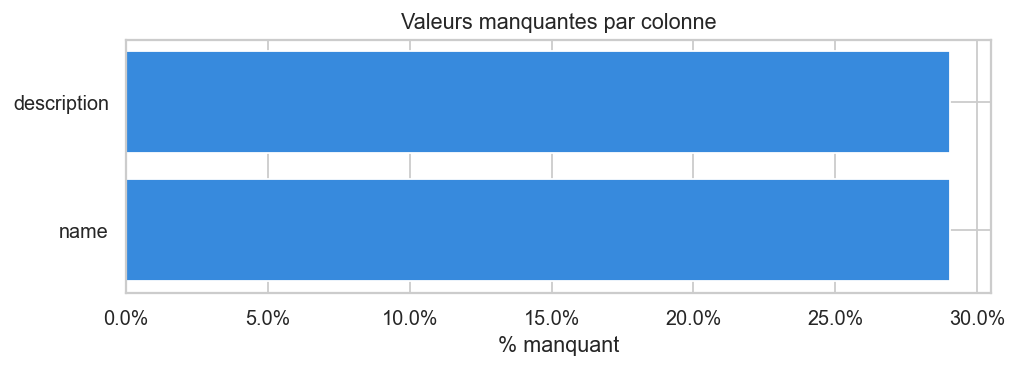

,% manquant
name,29.032258
description,29.032258


In [11]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print('✅ Aucune valeur manquante')
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.5)))
    ax.barh(missing.index, missing.values, color='#378ADD')
    ax.set_xlabel('% manquant')
    ax.set_title('Valeurs manquantes par colonne')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.show()
    display(missing.rename('% manquant').to_frame())

## 4. Doublons

In [12]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

Doublons : 0 (0.00%)


## 5. Préparation des colonnes clés

In [13]:
# Extraction lat/lon depuis geo_point_2d
coords = df['geo_point_2d'].str.split(',', expand=True)
df['lat'] = pd.to_numeric(coords[0], errors='coerce')
df['lon'] = pd.to_numeric(coords[1], errors='coerce')

# Département depuis code postal
df['departement'] = df['code_postal'].astype(str).str[:2]

# Nettoyage description
df['description'] = df['description'].str.strip()

print("Colonnes disponibles :", df.columns.tolist())
print(f"Lat range : {df['lat'].min():.5f} → {df['lat'].max():.5f}")
print(f"Lon range : {df['lon'].min():.5f} → {df['lon'].max():.5f}")

Colonnes disponibles : ['name', 'description', 'geometry', 'geo_point_2d', 'code_postal', 'lat', 'lon', 'departement']
Lat range : 48.73640 → 48.96076
Lon range : 2.17801 → 2.55319


## 6. Répartition par département

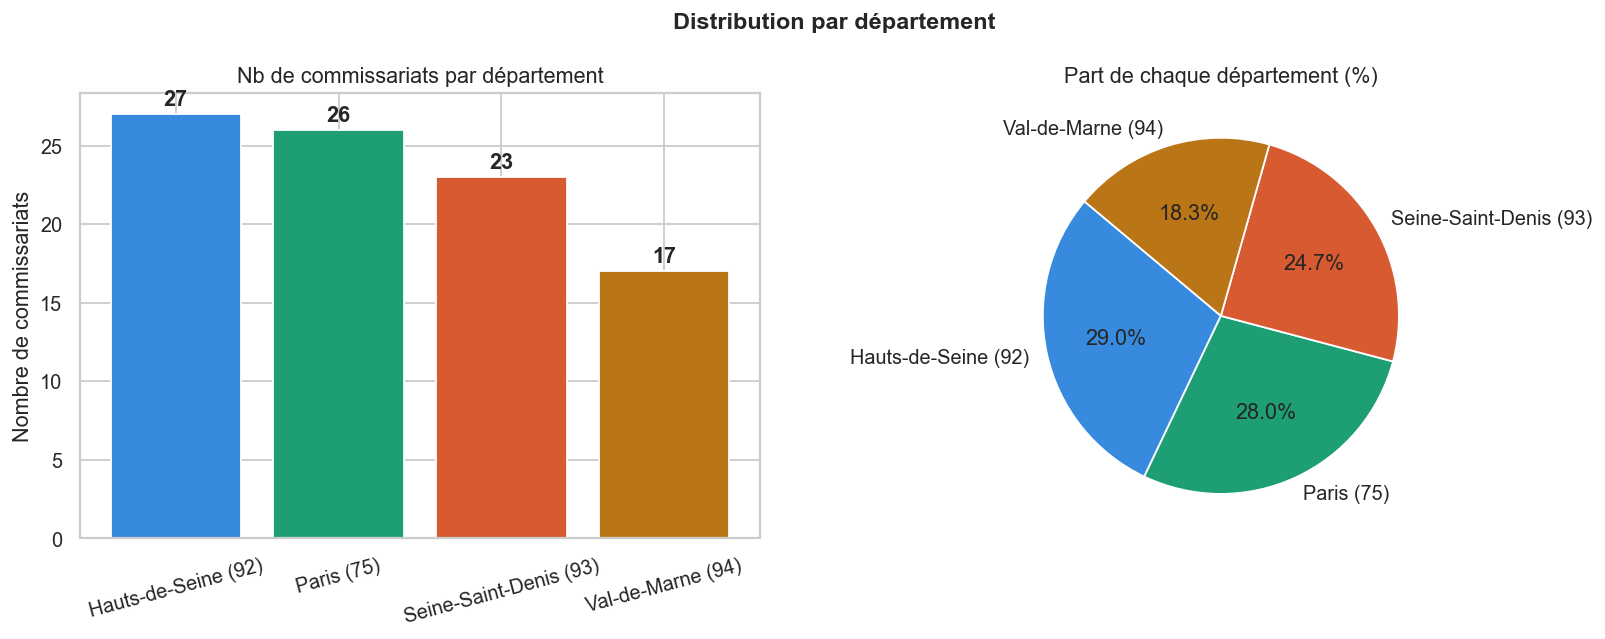

,Département,Commissariats
0,Hauts-de-Seine (92),27
1,Paris (75),26
2,Seine-Saint-Denis (93),23
3,Val-de-Marne (94),17


In [14]:
DEPT_LABELS = {
    '75': 'Paris (75)', '92': 'Hauts-de-Seine (92)',
    '93': 'Seine-Saint-Denis (93)', '94': 'Val-de-Marne (94)'
}

vc_dept = df['departement'].value_counts().reset_index()
vc_dept.columns = ['dept', 'count']
vc_dept['label'] = vc_dept['dept'].map(DEPT_LABELS).fillna(vc_dept['dept'])
vc_dept = vc_dept.sort_values('count', ascending=False)

colors = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(vc_dept['label'], vc_dept['count'], color=colors[:len(vc_dept)])
ax1.set_title("Nb de commissariats par département")
ax1.set_ylabel("Nombre de commissariats")
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(ax1.patches, vc_dept['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontweight='bold')

ax2.pie(vc_dept['count'], labels=vc_dept['label'], autopct='%1.1f%%',
        colors=colors[:len(vc_dept)], startangle=140)
ax2.set_title("Part de chaque département (%)")

plt.suptitle("Distribution par département", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(vc_dept[['label', 'count']].rename(columns={'label': 'Département', 'count': 'Commissariats'}))

## 8. Distribution par code postal (Top 20)

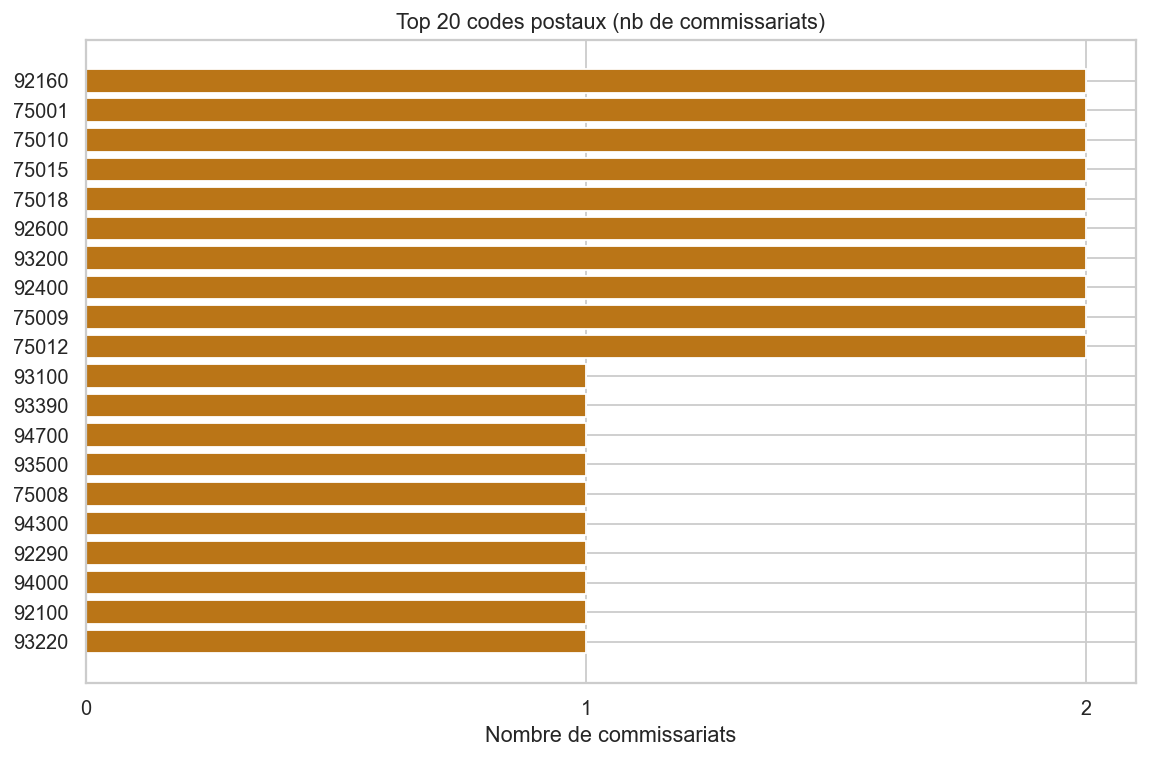

,Code postal,Commissariats
0,92160,2
1,75001,2
2,75010,2
3,75015,2
4,75018,2
5,92600,2
6,93200,2
7,92400,2
8,75009,2
9,75012,2


In [16]:
top_cp = df['code_postal'].value_counts().head(20).reset_index()
top_cp.columns = ['code_postal', 'count']

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_cp['code_postal'].astype(str), top_cp['count'], color='#BA7517')
ax.set_title("Top 20 codes postaux (nb de commissariats)")
ax.set_xlabel("Nombre de commissariats")
ax.invert_yaxis()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

display(top_cp.rename(columns={'code_postal': 'Code postal', 'count': 'Commissariats'}))

## 9. Paris — commissariats par arrondissement

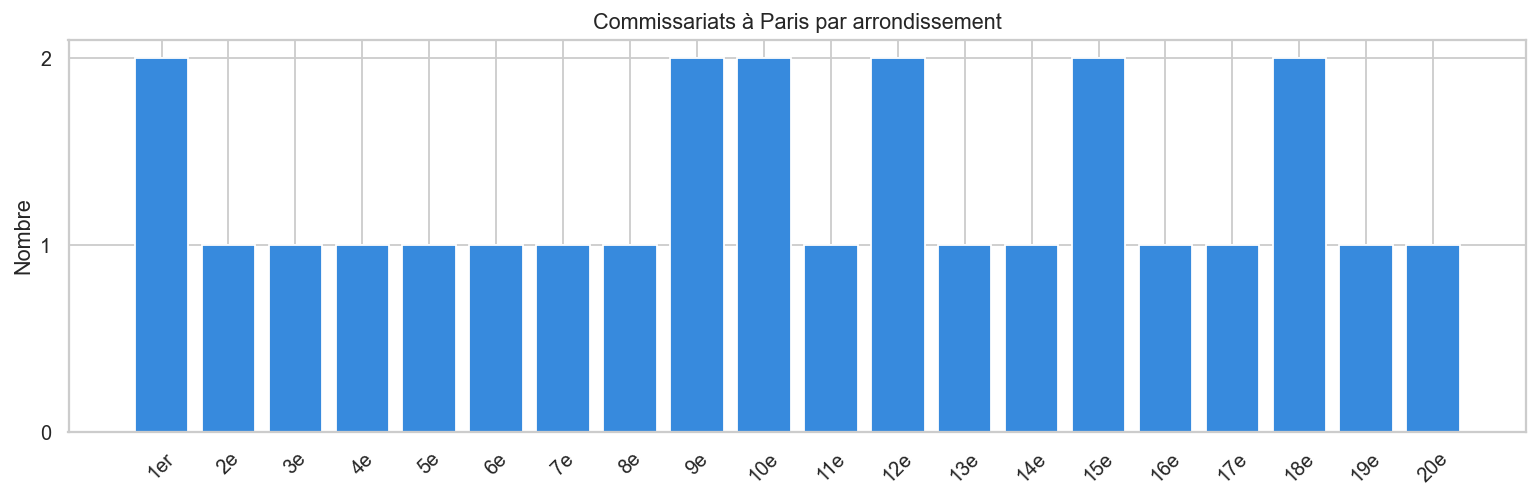

Arrondissements couverts : 20 / 20
Arrondissements avec > 1 commissariat : 6


In [17]:
paris = df[df['departement'] == '75'].copy()

vc_arr = paris['code_postal'].value_counts().sort_index().reset_index()
vc_arr.columns = ['code_postal', 'count']

def arrdt_label(cp):
    n = str(cp)[-2:].lstrip('0') or '0'
    return n + ('er' if n == '1' else 'e')

vc_arr['arrdt'] = vc_arr['code_postal'].apply(arrdt_label)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(vc_arr['arrdt'], vc_arr['count'], color='#378ADD')
ax.set_title("Commissariats à Paris par arrondissement")
ax.set_ylabel("Nombre")
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(f"Arrondissements couverts : {vc_arr['code_postal'].nunique()} / 20")
print(f"Arrondissements avec > 1 commissariat : {(vc_arr['count'] > 1).sum()}")

## 10. Distribution géographique

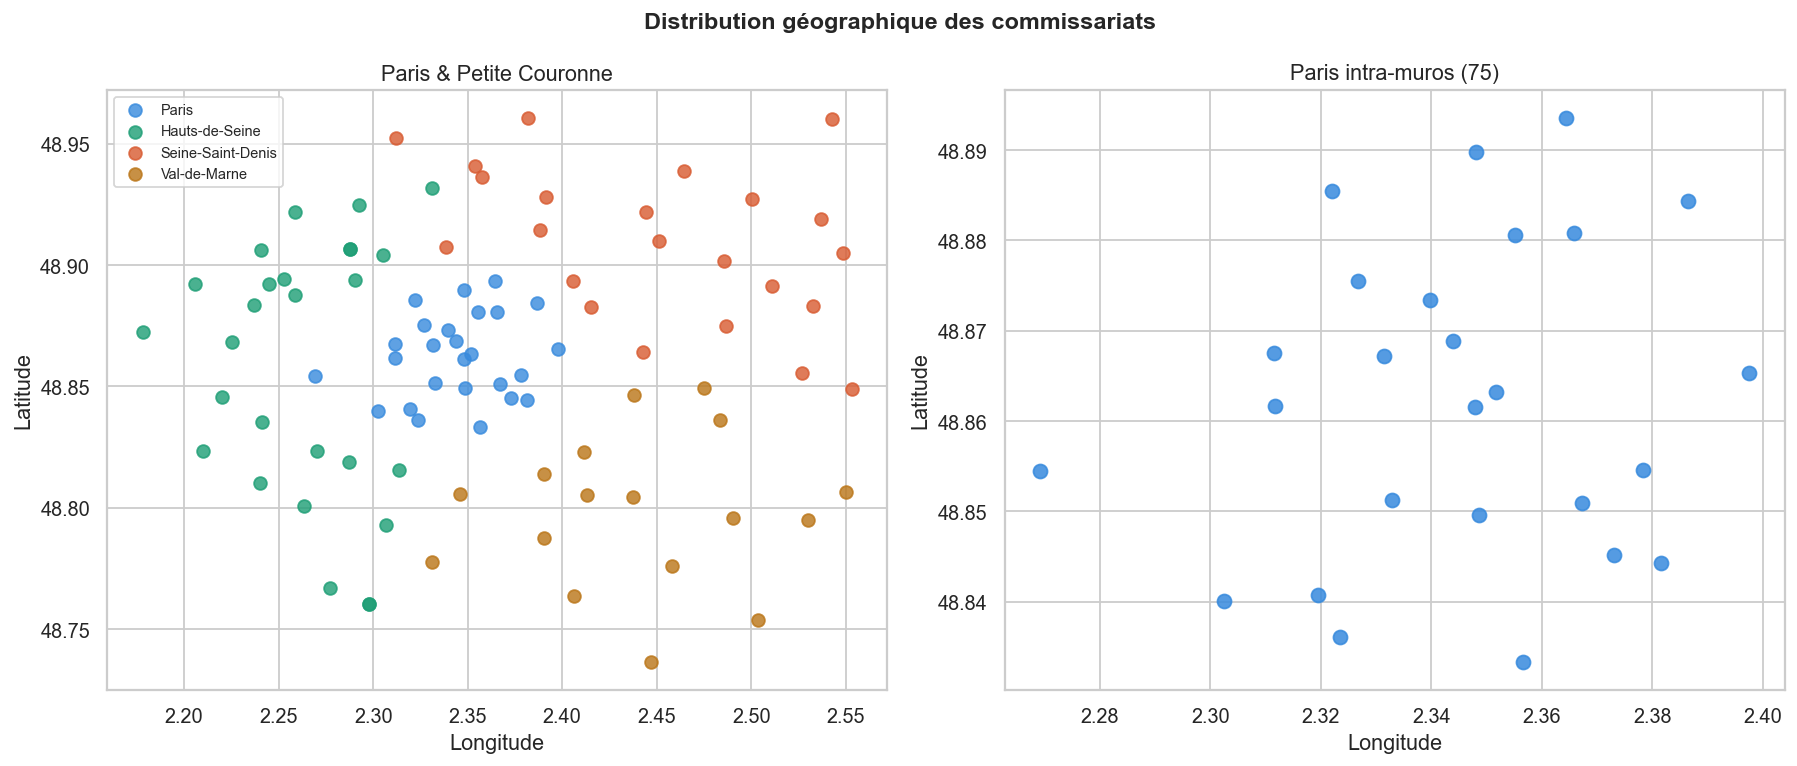

In [18]:
geo = df[['lat', 'lon', 'departement']].dropna()

dept_colors = {'75': '#378ADD', '92': '#1D9E75', '93': '#D85A30', '94': '#BA7517'}
dept_names  = {'75': 'Paris', '92': 'Hauts-de-Seine',
               '93': 'Seine-Saint-Denis', '94': 'Val-de-Marne'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Vue globale colorée par département
for dept, grp in geo.groupby('departement'):
    c     = dept_colors.get(dept, '#888780')
    label = dept_names.get(dept, dept)
    axes[0].scatter(grp['lon'], grp['lat'], s=50, alpha=0.8, color=c, label=label)

axes[0].set_title("Paris & Petite Couronne")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend(fontsize=8)

# Zoom Paris intra-muros
paris_geo = geo[geo['departement'] == '75']
axes[1].scatter(paris_geo['lon'], paris_geo['lat'], s=60, alpha=0.85, color='#378ADD')
axes[1].set_title("Paris intra-muros (75)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Distribution géographique des commissariats", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Cardinalité des colonnes catégorielles

In [19]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
# Exclut les colonnes techniques brutes
cat_cols = [c for c in cat_cols if c not in ['geometry', 'geo_point_2d']]

cardinality = pd.DataFrame({
    'colonne'    : cat_cols,
    'unique'     : [df[c].nunique() for c in cat_cols],
    'exemple'    : [df[c].dropna().iloc[0] if not df[c].dropna().empty else 'N/A' for c in cat_cols],
    '% manquant' : [round(df[c].isnull().mean() * 100, 1) for c in cat_cols],
}).sort_values('unique', ascending=False)

display(cardinality)

,colonne,unique,exemple,% manquant
0,name,66,ANTONY,29.0
2,departement,4,92,0.0
1,description,3,Commissariat central,29.0


## 12. Résumé final

In [20]:
print('=' * 55)
print('RÉSUMÉ EDA — commissariats_avec_code_postal.csv')
print('=' * 55)
print(f'  Lignes            : {len(df):,}')
print(f'  Colonnes          : {len(df.columns)}')
print(f'  Doublons          : {df.duplicated().sum()}')
missing_count = (df.isnull().sum() > 0).sum()
print(f'  Cols avec NaN     : {missing_count}')
print(f'  Départements      : {df["departement"].nunique()} → {sorted(df["departement"].unique())}')
print(f'  Codes postaux     : {df["code_postal"].nunique()} uniques')
print(f'  Lat range         : {df["lat"].min():.5f} → {df["lat"].max():.5f}')
print(f'  Lon range         : {df["lon"].min():.5f} → {df["lon"].max():.5f}')
print('=' * 55)

RÉSUMÉ EDA — commissariats_avec_code_postal.csv
  Lignes            : 93
  Colonnes          : 8
  Doublons          : 0
  Cols avec NaN     : 2
  Départements      : 4 → ['75', '92', '93', '94']
  Codes postaux     : 83 uniques
  Lat range         : 48.73640 → 48.96076
  Lon range         : 2.17801 → 2.55319
